In [ ]:
import numpy as np
import matplotlib.pyplot as plt


In [ ]:
def logistic(x, r):
    return r * x * (1 - x)


In [ ]:
def simulate_cml(r, p, x0, steps):

    x0 = np.array(x0, dtype=float)
    n = len(x0)

    history = np.zeros((steps + 1, n))
    history[0] = x0

    for t in range(steps):

        curr = history[t]

        # periodic boundary
        left = np.roll(curr, 1)
        right = np.roll(curr, -1)

        f_self = logistic(curr, r)
        f_left = logistic(left, r)
        f_right = logistic(right, r)

        next_state = (1 - p) * f_self + (p / 2.0) * (f_left + f_right)

        history[t + 1] = next_state

    return history


In [ ]:
np.random.seed(42)

N = 100
r = 3.99
p = 0.5
steps = 2000

x0 = np.random.rand(N)

data = simulate_cml(r, p, x0, steps)

print("Final state:")
print(data[-1])


Final state:
[0.92784118 0.94038454 0.96783466 0.98652105 0.95534498 0.86619201
 0.83529643 0.89857587 0.8652673  0.67429097 0.44882884 0.32163678
 0.34077346 0.37112157 0.43840098 0.68302511 0.87663362 0.88613777
 0.91384132 0.97174764 0.98121273 0.9724044  0.89707662 0.73436227
 0.62604701 0.64614666 0.76292372 0.90568232 0.97768011 0.96249108
 0.85262999 0.73707273 0.7867913  0.87465408 0.78996353 0.66699578
 0.63830038 0.6649997  0.77323244 0.83315766 0.66915753 0.43990883
 0.31074824 0.23355797 0.32478967 0.65024181 0.90515271 0.93115514
 0.74079823 0.43476558 0.38135589 0.64208346 0.87428317 0.93386866
 0.90281927 0.76259532 0.46112704 0.23747493 0.3963442  0.75999591
 0.95203228 0.97964356 0.9865066  0.98884331 0.98973432 0.99055821
 0.89991294 0.63889239 0.51566053 0.72986083 0.93918897 0.92133632
 0.81345831 0.83132821 0.908769   0.92526629 0.89768683 0.84748727
 0.85521271 0.8595686  0.86606914 0.84272876 0.70299512 0.59228765
 0.47827205 0.28065361 0.16131198 0.18947213 0.23

In [ ]:
def bifurcation_data():

    N = 100
    p = 0.5
    r_values = np.linspace(3.0, 4.0, 600)

    steps = 2000
    cut = 1500   # remove transient

    r_plot = []
    x_plot = []

    x_current = np.random.rand(N)

    for r in r_values:

        result = simulate_cml(r, p, x_current, steps)

        steady_part = result[cut:]

        for state in steady_part:
            r_plot.append(r)
            x_plot.append(state[0])  # only first lattice site

        # continuation
        x_current = result[-1]

    return np.array(r_plot), np.array(x_plot)


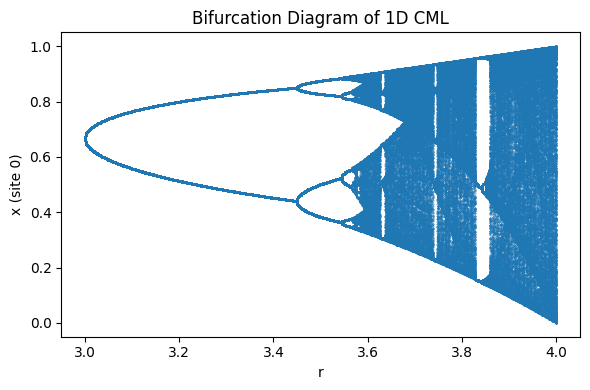

In [ ]:
np.random.seed(42)

A, X = bifurcation_data()

plt.figure(figsize=(6, 4))
plt.scatter(A, X, s=0.1)
plt.xlabel("r")
plt.ylabel("x (site 0)")
plt.title("Bifurcation Diagram of 1D CML")
plt.tight_layout()
plt.show()


In [ ]:
# sine map
def sine_map(x, a):
    return (4.0 / (a - 0.5)) * np.sin(np.pi * x)


# chebyshev map for coupling update
def chebyshev(p, b):
    return np.cos(b * np.arccos(p))

In [ ]:
def simulate_cicml(a, b, p0, x0, steps):

    x0 = np.array(x0, dtype=float)
    n = len(x0)

    states = np.zeros((steps + 1, n))
    coupling_vals = np.zeros(steps + 1)

    states[0] = x0
    coupling_vals[0] = p0

    for t in range(steps):

        curr = states[t]
        p = coupling_vals[t]

        # periodic boundary
        left = np.roll(curr, 1)
        right = np.roll(curr, -1)

        g_self = sine_map(curr, a)
        g_left = sine_map(left, a)
        g_right = sine_map(right, a)

        # CICML update (mod 1 keeps values in [0,1])
        next_state = (1 - p) * g_self + (p / 2.0) * (g_left + g_right)
        states[t + 1] = np.mod(next_state, 1.0)

        # update coupling using chebyshev
        coupling_vals[t + 1] = chebyshev(p, b)

    return states, coupling_vals

In [ ]:
np.random.seed(42)

N = 100
a = 3.9
b = 5
p0 = 0.3
steps = 2000

x0 = np.random.rand(N)

X, P = simulate_cicml(a, b, p0, x0, steps)

print("Final lattice state:")
print(X[-1])

print("\nFinal coupling value:")
print(P[-1])
def bifurcation_cicml():

    N = 71
    b = 5
    p0 = 0.3

    r_values = np.linspace(3.57, 4.0, 600)

    steps = 3000
    cut = 2000   # remove transient

    r_plot = []
    x_plot = []

    for a in r_values:

        x0 = np.random.rand(N)

        X, P = simulate_cicml(a, b, p0, x0, steps)

        steady_part = X[cut:]

        for state in steady_part:
            r_plot.append(a)
            x_plot.append(state[0])   # first site only

    return np.array(r_plot), np.array(x_plot)

Final lattice state:
[0.58129494 0.01817309 0.88606988 0.43417347 0.74853061 0.5084168
 0.72976652 0.25209796 0.95094408 0.14369646 0.98549305 0.20749032
 0.01477454 0.83507802 0.4840152  0.07373806 0.85132171 0.66745943
 0.63062128 0.28234406 0.63687944 0.4554658  0.47630129 0.75552416
 0.26750669 0.94725761 0.12938514 0.17951436 0.44916536 0.57670419
 0.80991983 0.86366347 0.89074172 0.78274491 0.76631103 0.52703814
 0.92139646 0.15406301 0.85510045 0.45407814 0.44507825 0.91409015
 0.21388283 0.72721181 0.42612815 0.93051439 0.34524025 0.68067044
 0.84656495 0.24852019 0.53728852 0.49086864 0.4885279  0.52383329
 0.22417744 0.12603316 0.3204832  0.97803403 0.61507958 0.59010272
 0.59344271 0.32152642 0.06533997 0.00176488 0.04281473 0.47363612
 0.68445985 0.07884544 0.65730393 0.58457764 0.93297402 0.9074736
 0.27234591 0.18223129 0.55048252 0.44501842 0.3212561  0.79392817
 0.79155622 0.96296409 0.22273221 0.38126055 0.74313262 0.0890313
 0.6113869  0.1374511  0.24979023 0.73510824

In [ ]:
def bifurcation_cicml():

    N = 71
    b = 5
    p0 = 0.3

    r_values = np.linspace(3.57, 4.0, 600)

    steps = 3000
    cut = 2000   # remove transient

    r_plot = []
    x_plot = []

    for a in r_values:

        x0 = np.random.rand(N)

        X, P = simulate_cicml(a, b, p0, x0, steps)

        steady_part = X[cut:]

        for state in steady_part:
            r_plot.append(a)
            x_plot.append(state[0])   # first site only

    return np.array(r_plot), np.array(x_plot)


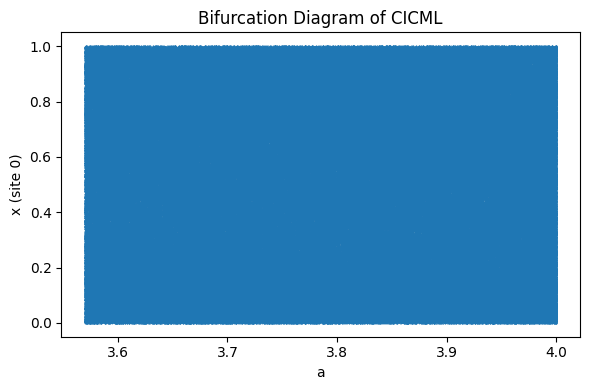

In [ ]:
np.random.seed(42)

A, X = bifurcation_cicml()

plt.figure(figsize=(6,4))
plt.scatter(A, X, s=0.1)
plt.xlabel("a")
plt.ylabel("x (site 0)")
plt.title("Bifurcation Diagram of CICML")
plt.tight_layout()
plt.show()


In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def plot_spatiotemporal(X, title="Spatiotemporal Map"):

    plt.figure(figsize=(8, 5))
    plt.imshow(X, aspect='auto', cmap='jet')
    plt.colorbar(label="State value")
    plt.xlabel("Lattice index")
    plt.ylabel("Time iteration")
    plt.title(title)
    plt.tight_layout()
    plt.show()

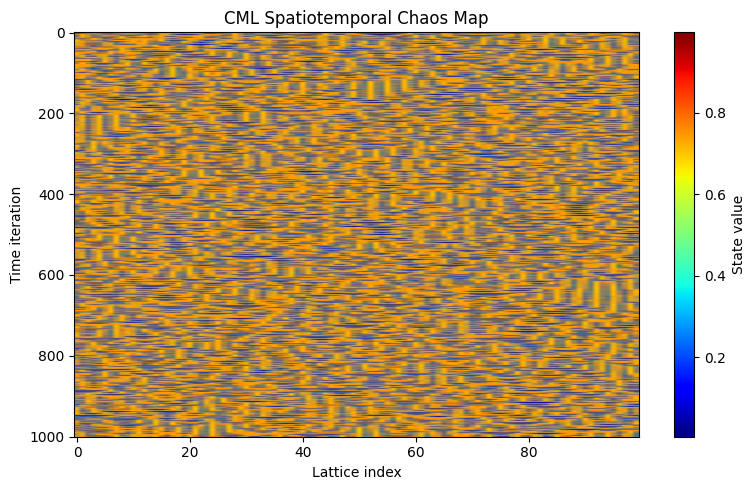

In [ ]:
# simulate first 1000 iterations
np.random.seed(42)

N = 100
steps = 1000
a = 3.99
p = 0.5

x0 = np.random.rand(N)

X = simulate_cml(a, p, x0, steps)

plot_spatiotemporal(X, "CML Spatiotemporal Chaos Map")

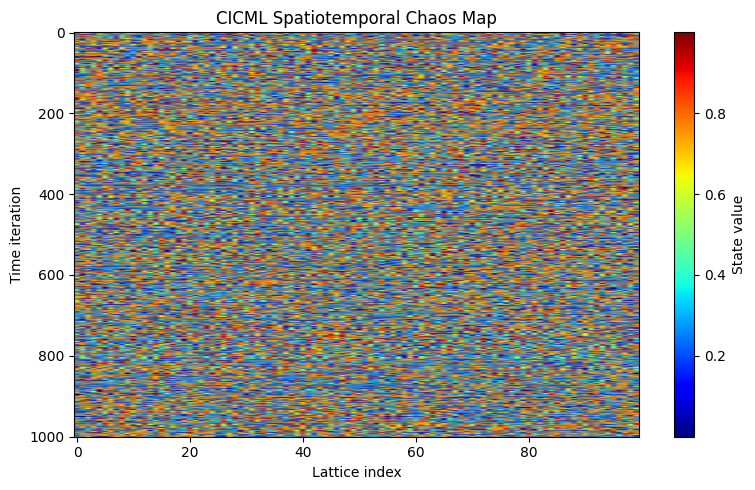

In [ ]:
np.random.seed(42)

N = 100
steps = 1000
a = 3.99
b = 5
p0 = 0.3

x0 = np.random.rand(N)

X_cicml, P = simulate_cicml(a, b, p0, x0, steps)

plot_spatiotemporal(X_cicml, "CICML Spatiotemporal Chaos Map")

In [ ]:
def lyapunov_cml(X, a, p):

    T, N = X.shape
    lyap = np.zeros(N)

    for i in range(N):
        vals = []
        for t in range(T - 1):
            x = X[t, i]
            derivative = a * (1 - 2 * x)
            vals.append(np.log(abs(derivative) + 1e-12))
        lyap[i] = np.mean(vals)

    return lyap

In [ ]:
def lyapunov_cicml(X, a):

    T, N = X.shape
    lyap = np.zeros(N)

    for i in range(N):
        vals = []
        for t in range(T - 1):
            x = X[t, i]
            derivative = (4.0 * np.pi / (a - 0.5)) * np.cos(np.pi * x)
            vals.append(np.log(abs(derivative) + 1e-12))
        lyap[i] = np.mean(vals)

    return lyap

In [ ]:
def compute_kse(lyap_vals):

    N = len(lyap_vals)

    positive = lyap_vals[lyap_vals > 0]

    ked = np.sum(positive) / N
    keb = len(positive) / N

    return ked, keb

In [ ]:
lyap_cml = lyapunov_cml(X, a, p)
ked_cml, keb_cml = compute_kse(lyap_cml)

print("CML KED:", ked_cml)
print("CML KEB:", keb_cml)

CML KED: 0.4226532432846353
CML KEB: 1.0


In [ ]:
def information_entropy(data, bins=256):

    hist, _ = np.histogram(data, bins=bins, range=(0, 1), density=True)

    hist = hist[hist > 0]

    entropy = -np.sum(hist * np.log2(hist))

    return entropy

In [ ]:
entropy_cml = information_entropy(X.flatten())
entropy_cicml = information_entropy(X_cicml.flatten())

print("CML Entropy:", entropy_cml)
print("CICML Entropy:", entropy_cicml)

print("Ideal Entropy (log2 256):", np.log2(256))

CML Entropy: -66.22371791248739
CICML Entropy: -3.325598523844533
Ideal Entropy (log2 256): 8.0


CML Largest Lyapunov: 0.36525013157521363
CML KED: 0.07806084689263476
CML KEB: 0.38

CICSML Largest Lyapunov: 0.6935150221280112
CICSML KED: 0.38849392716500897
CICSML KEB: 0.84


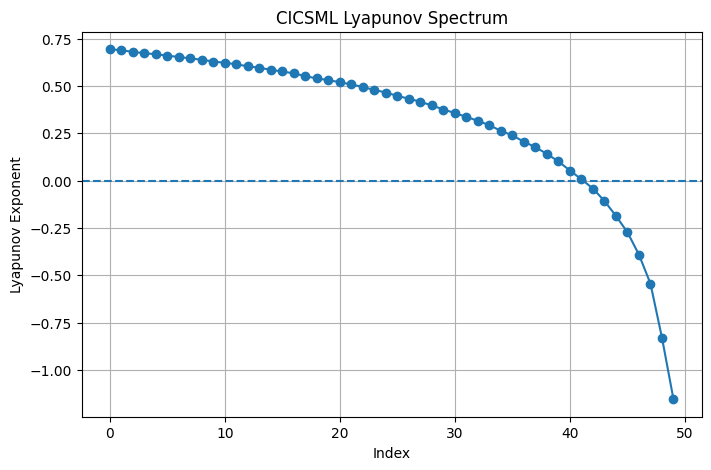

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

# ==========================================================
# 1. Local Maps
# ==========================================================

# Logistic map (for CML)
def logistic(x, a):
    return a * x * (1 - x)

def d_logistic(x, a):
    return a * (1 - 2*x)


# Strongly chaotic sine map (for CICSML)
def sine_map(x, a):
    return a * np.sin(np.pi * x)

def d_sine_map(x, a):
    return a * np.pi * np.cos(np.pi * x)


# Chebyshev map for dynamic coupling
def chebyshev(p, b):
    p = np.clip(p, -1.0, 1.0)
    return np.cos(b * np.arccos(p))


# ==========================================================
# 2. Jacobians (Vectorized)
# ==========================================================

def jacobian_cml(x, a, p):
    N = len(x)
    fprime = d_logistic(x, a)
    J = np.zeros((N, N))

    idx = np.arange(N)
    left = (idx - 1) % N
    right = (idx + 1) % N

    J[idx, idx] = (1 - p) * fprime
    J[idx, left] += (p/2) * fprime[left]
    J[idx, right] += (p/2) * fprime[right]

    return J


def jacobian_cicsml(x, a, p):
    N = len(x)
    gprime = d_sine_map(x, a)
    J = np.zeros((N, N))

    idx = np.arange(N)
    left = (idx - 1) % N
    right = (idx + 1) % N

    J[idx, idx] = (1 - p) * gprime
    J[idx, left] += (p/2) * gprime[left]
    J[idx, right] += (p/2) * gprime[right]

    return J


# ==========================================================
# 3. Lyapunov Spectrum via QR Method
# ==========================================================

def lyapunov_spectrum_cml(a, p, x0, steps, transient=1000):

    x = np.array(x0, dtype=float)
    N = len(x)

    # Burn-in
    for _ in range(transient):
        left = np.roll(x, 1)
        right = np.roll(x, -1)
        x = (1 - p) * logistic(x, a) + (p/2) * (
            logistic(left, a) + logistic(right, a)
        )

    Q = np.eye(N)
    lyap_sum = np.zeros(N)

    for _ in range(steps):

        J = jacobian_cml(x, a, p)
        Z = J @ Q
        Q, R = np.linalg.qr(Z)

        lyap_sum += np.log(np.abs(np.diag(R)) + 1e-300)

        left = np.roll(x, 1)
        right = np.roll(x, -1)
        x = (1 - p) * logistic(x, a) + (p/2) * (
            logistic(left, a) + logistic(right, a)
        )

    return lyap_sum / steps


def lyapunov_spectrum_cicsml(a, b, p0, x0, steps, transient=1000):

    x = np.array(x0, dtype=float)
    p = float(p0)
    N = len(x)

    # Burn-in
    for _ in range(transient):
        left = np.roll(x, 1)
        right = np.roll(x, -1)

        gx = sine_map(x, a)
        gxL = sine_map(left, a)
        gxR = sine_map(right, a)

        x = np.mod((1 - p) * gx + (p/2) * (gxL + gxR), 1.0)
        p = chebyshev(p, b)

    Q = np.eye(N)
    lyap_sum = np.zeros(N)

    for _ in range(steps):

        J = jacobian_cicsml(x, a, p)
        Z = J @ Q
        Q, R = np.linalg.qr(Z)

        lyap_sum += np.log(np.abs(np.diag(R)) + 1e-300)

        left = np.roll(x, 1)
        right = np.roll(x, -1)

        gx = sine_map(x, a)
        gxL = sine_map(left, a)
        gxR = sine_map(right, a)

        x = np.mod((1 - p) * gx + (p/2) * (gxL + gxR), 1.0)
        p = chebyshev(p, b)

    return lyap_sum / steps


# ==========================================================
# 4. KSE Metrics
# ==========================================================

def compute_kse(lambdas):
    N = len(lambdas)
    positive = lambdas[lambdas > 0]

    KED = positive.sum() / N
    KEB = len(positive) / N

    return KED, KEB


# ==========================================================
# 5. Run Example
# ==========================================================

if __name__ == "__main__":

    N = 50
    steps = 8000
    transient = 1000

    x0 = 0.5 + 0.01 * (2*np.random.rand(N) - 1)

    # -------- CML --------
    a_cml = 3.99
    p_cml = 0.5

    lambdas_cml = lyapunov_spectrum_cml(a_cml, p_cml, x0, steps, transient)
    KED_cml, KEB_cml = compute_kse(lambdas_cml)

    print("CML Largest Lyapunov:", np.max(lambdas_cml))
    print("CML KED:", KED_cml)
    print("CML KEB:", KEB_cml)

    # -------- Chaotic CICSML --------
    a_cicsml = 1.0   # strong chaos
    b_cicsml = 4.0
    p0 = 0.2         # moderate coupling

    lambdas_cicsml = lyapunov_spectrum_cicsml(a_cicsml, b_cicsml, p0, x0, steps, transient)
    KED_cicsml, KEB_cicsml = compute_kse(lambdas_cicsml)

    print("\nCICSML Largest Lyapunov:", np.max(lambdas_cicsml))
    print("CICSML KED:", KED_cicsml)
    print("CICSML KEB:", KEB_cicsml)

    # Plot spectrum
    plt.figure(figsize=(8,5))
    plt.plot(np.sort(lambdas_cicsml)[::-1], marker='o')
    plt.axhline(0, linestyle='--')
    plt.title("CICSML Lyapunov Spectrum")
    plt.xlabel("Index")
    plt.ylabel("Lyapunov Exponent")
    plt.grid(True)
    plt.show()

CML average entropy H: 3.1478018046161425
CML average H_max: 3.459431618637298
CML average number of states per lattice: 11.0

CICSML average entropy H: 1.0
CICSML average H_max: 1.0
CICSML average number of states per lattice: 2.0


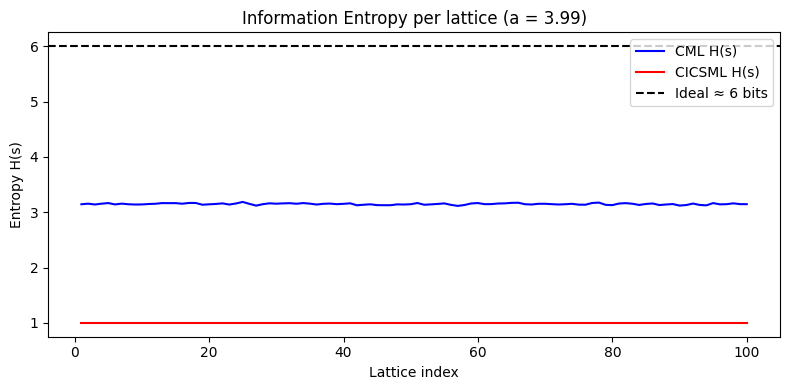

In [ ]:
import numpy as np

# ---------- 1. Helpers: simulate CML / CICSML lattice time-series ----------

def logistic(x, a):
    return a * x * (1.0 - x)

def sine_map(x, a):
    # CICSML improved sine map[page:1]
    return (4.0 / (a - 0.5)) * np.sin(np.pi * x)

def chebyshev(p, b):
    p = np.clip(p, -1.0, 1.0)
    return np.cos(b * np.arccos(p))

def simulate_cml_lattice(a, p, x0, steps):
    """
    Simulate CML for 'steps' iterations and return array of shape (steps, N).[page:1]
    """
    x = np.array(x0, dtype=float)
    N = len(x)
    history = np.zeros((steps, N), dtype=float)
    for t in range(steps):
        history[t] = x
        left = np.roll(x, 1)
        right = np.roll(x, -1)
        gx = logistic(x, a)
        gxL = logistic(left, a)
        gxR = logistic(right, a)
        x = (1.0 - p) * gx + (p / 2.0) * (gxL + gxR)
    return history

def simulate_cicsml_lattice(a, b, p0, x0, steps):
    """
    Simulate CICSML for 'steps' iterations and return array of shape (steps, N).[page:1]
    """
    x = np.array(x0, dtype=float)
    p = float(p0)
    N = len(x)
    history = np.zeros((steps, N), dtype=float)
    for t in range(steps):
        history[t] = x
        left = np.roll(x, 1)
        right = np.roll(x, -1)
        gx = sine_map(x, a)
        gxL = sine_map(left, a)
        gxR = sine_map(right, a)
        x = np.mod((1.0 - p) * gx + (p / 2.0) * (gxL + gxR), 1.0)
        p = chebyshev(p, b)
    return history

# ---------- 2. Information entropy on lattice states (Eqs. (9)–(10)) ----------[page:1]

def lattice_state_entropy(time_series, decimals=1):
    """
    time_series: 1D array of values of a single lattice over time.
    'decimals' = 1 implements the paper's rule: same first decimal place = same state.[page:1]
    """
    # quantize by first decimal place
    factor = 10 ** decimals
    # round to one decimal place (or equivalently floor(x*10)/10 etc.)
    states = np.round(time_series * factor) / factor

    # compute probabilities P(s_i)
    unique, counts = np.unique(states, return_counts=True)
    probs = counts.astype(float) / counts.sum()

    # H(s) = -sum P(si) log2 P(si)[page:1]
    H = -np.sum(probs * np.log2(probs + 1e-300))

    # n = number of all states within a lattice, H_max = log2 n[page:1]
    n = len(unique)
    if n > 0:
        H_max = np.log2(n)
    else:
        H_max = 0.0

    return H, H_max, n

def information_entropy_analysis(system="CML",
                                 a=3.99,
                                 p=0.5,
                                 b=4.0,
                                 p0=0.5,
                                 N=100,
                                 steps=5000,
                                 burn_in=1000,
                                 decimals=1,
                                 seed=1234):
    """
    Implements Section II-E:
    - select first 100 cells (N)
    - simulate lattice
    - define states by same first decimal place
    - compute H(s) and H_max for each lattice.[page:1]
    Returns arrays of entropies and ideal entropies.
    """
    rng = np.random.default_rng(seed)
    x0 = 0.5 + 0.01 * (2 * rng.random(N) - 1)

    # simulate after burn-in
    if system == "CML":
        hist = simulate_cml_lattice(a, p, x0, steps + burn_in)
    else:
        hist = simulate_cicsml_lattice(a, b, p0, x0, steps + burn_in)

    # drop burn-in
    hist = hist[burn_in:]   # shape (steps, N)

    H_list = []
    Hmax_list = []
    n_states_list = []

    # “each lattice” = each spatial index i[page:1]
    for i in range(N):
        ts_i = hist[:, i]
        H, H_max, n = lattice_state_entropy(ts_i, decimals=decimals)
        H_list.append(H)
        Hmax_list.append(H_max)
        n_states_list.append(n)

    return np.array(H_list), np.array(Hmax_list), np.array(n_states_list)

# ---------- 3. Example usage to reproduce Fig. 4-style analysis ----------[page:1]

if __name__ == "__main__":
    N = 100       # first 100 cells, as in the section[page:1]
    steps = 5000
    burn_in = 1000

    # CML
    a_cml = 3.99
    p_cml = 0.5
    H_cml, Hmax_cml, n_cml = information_entropy_analysis(
        system="CML",
        a=a_cml,
        p=p_cml,
        N=N,
        steps=steps,
        burn_in=burn_in,
        decimals=1
    )

    print("CML average entropy H:", np.mean(H_cml))
    print("CML average H_max:", np.mean(Hmax_cml))
    print("CML average number of states per lattice:", np.mean(n_cml))

    # CICSML
    a_cics = 3.99
    b_cics = 4.0
    p0 = 0.5

    H_cics, Hmax_cics, n_cics = information_entropy_analysis(
        system="CICSML",
        a=a_cics,
        b=b_cics,
        p0=p0,
        N=N,
        steps=steps,
        burn_in=burn_in,
        decimals=1
    )

    print("\nCICSML average entropy H:", np.mean(H_cics))
    print("CICSML average H_max:", np.mean(Hmax_cics))
    print("CICSML average number of states per lattice:", np.mean(n_cics))

    # Optional: plot H for first 100 cells like Fig. 4[page:1]
    import matplotlib.pyplot as plt

    cells = np.arange(1, N + 1)

    plt.figure(figsize=(8, 4))
    plt.plot(cells, H_cml, 'b-', label='CML H(s)')
    plt.plot(cells, H_cics, 'r-', label='CICSML H(s)')
    plt.axhline(6.0, color='k', linestyle='--', label='Ideal ≈ 6 bits')  # as in paper[page:1]
    plt.xlabel('Lattice index')
    plt.ylabel('Entropy H(s)')
    plt.title('Information Entropy per lattice (a = 3.99)')
    plt.legend()
    plt.tight_layout()
    plt.show()


In [ ]:
from mpl_toolkits.mplot3d import Axes3D

def plot_kse_surface(system="cml"):

    N = 50
    steps = 4000
    transient = 800

    a_vals = np.linspace(3.0, 3.99, 15)
    p_vals = np.linspace(0.0, 1.0, 15)

    A, P = np.meshgrid(a_vals, p_vals)

    KED_grid = np.zeros_like(A)
    KEB_grid = np.zeros_like(A)

    x0 = 0.5 + 0.01 * (2*np.random.rand(N) - 1)

    for i in range(len(p_vals)):
        for j in range(len(a_vals)):

            a = a_vals[j]
            p = p_vals[i]

            if system == "cml":
                lambdas = lyapunov_spectrum_cml(a, p, x0, steps, transient)
            else:
                lambdas = lyapunov_spectrum_cicsml(1.0, 4.0, p, x0, steps, transient)

            KED, KEB = compute_kse(lambdas)

            KED_grid[i, j] = KED
            KEB_grid[i, j] = KEB

            print(f"{system.upper()} done: a={a:.2f}, p={p:.2f}")

    # ---- Plot KED ----
    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(A, P, KED_grid, cmap='viridis')
    ax.set_xlabel('a')
    ax.set_ylabel('p')
    ax.set_zlabel('KED (h)')
    ax.set_title(f'{system.upper()} - KED')
    plt.show()

    # ---- Plot KEB ----
    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(A, P, KEB_grid, cmap='plasma')
    ax.set_xlabel('a')
    ax.set_ylabel('p')
    ax.set_zlabel('KEB (hu)')
    ax.set_title(f'{system.upper()} - KEB')
    plt.show()

In [ ]:
def plot_entropy_index_surface(system="cml"):

    N = 50
    steps = 6000
    transient = 1000

    p_vals = np.linspace(0.0, 1.0, 20)
    indices = np.arange(N)

    H = np.zeros((len(p_vals), N))

    x0 = 0.5 + 0.01 * (2*np.random.rand(N) - 1)

    for i, p in enumerate(p_vals):

        if system == "cml":
            lambdas = lyapunov_spectrum_cml(3.99, p, x0, steps, transient)
        else:
            lambdas = lyapunov_spectrum_cicsml(1.0, 4.0, p, x0, steps, transient)

        H[i, :] = lambdas

        print(f"{system.upper()} p = {p:.2f}")

    P, I = np.meshgrid(p_vals, indices)

    fig = plt.figure(figsize=(10,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(I.T, P.T, H, cmap='viridis')
    ax.set_xlabel('Lattice index i')
    ax.set_ylabel('Coupling p')
    ax.set_zlabel('Lyapunov Exponent')
    ax.set_title(f'{system.upper()} - Entropy Distribution')
    plt.show()

In [ ]:
plot_entropy_index_surface("cml")
plot_entropy_index_surface("cicsml")

In [ ]:
import numpy as np

# ---------- 1. CICSML map (same as before) ----------

def sine_map(x, a):
    return (4.0 / (a - 0.5)) * np.sin(np.pi * x)

def chebyshev(p, b):
    p = np.clip(p, -1.0, 1.0)
    return np.cos(b * np.arccos(p))

def step_cicsml_scalar(x, p, a, b):
    """
    1D simplification of CICSML for sequence generation:
        x_{n+1} = mod( (1 - p_n) g(x_n), 1 )
        p_{n+1} = cos(b arccos(p_n))[page:1]
    This is enough for generating a chaotic scalar sequence.
    """
    gx = sine_map(x, a)
    x_next = np.mod((1.0 - p) * gx, 1.0)
    p_next = chebyshev(p, b)
    return x_next, p_next

# ---------- 2. Generate long chaotic sequence and bits ----------

def generate_cicsml_bits(total_iters=100000,
                         discard=10000,
                         a=3.99,
                         b=4.0,
                         x0=0.123456789,
                         p0=0.5):
    """
    Implements the paper's NIST-test sequence:
    iterate 100,100,000 times and remove first 100,000 values.[page:1]
    Output: numpy array of bits (0/1).
    """
    x = float(x0)
    p = float(p0)

    # burn-in + kept
    seq_len = total_iters
    x_vals = np.empty(seq_len, dtype=np.float64)

    for i in range(seq_len):
        x, p = step_cicsml_scalar(x, p, a, b)
        x_vals[i] = x

    # discard first 'discard' values
    x_vals = x_vals[discard:]

    # map x in (0,1) to bits; simplest: threshold at 0.5
    bits = (x_vals > 0.5).astype(np.uint8)
    return bits

if __name__ == "__main__":
    # 1) Generate bit sequence for NIST
    bits = generate_cicsml_bits()

    print("Generated bits length:", len(bits))

    # 2) Save as ASCII '0'/'1' for NIST STS C implementation
    with open("cicsml_nist_sequence.txt", "w") as f:
        f.write("".join(str(b) for b in bits))

    print("Sequence saved to cicsml_nist_sequence.txt")

    # If you use a Python NIST library (e.g. 'nist_sts'), you would call it like:
    # from nist_sts import run_all_battery
    # results = run_all_battery(bits)
    # then check that all p-values > 0.01 and proportions > 0.96 as in Table I.[page:1]


Generated bits length: 0
Sequence saved to cicsml_nist_sequence.txt


In [ ]:
def plot_kse_surface_fast(system="cml"):

    N = 20                 # smaller lattice (faster)
    steps = 2000           # fewer iterations
    transient = 500

    a_vals = np.linspace(3.0, 3.99, 12)
    p_vals = np.linspace(0.0, 1.0, 12)

    A, P = np.meshgrid(a_vals, p_vals)

    KED = np.zeros_like(A)
    KEB = np.zeros_like(A)

    x0 = 0.5 + 0.01*(2*np.random.rand(N)-1)

    for i, p in enumerate(p_vals):
        for j, a in enumerate(a_vals):

            if system == "cml":
                lambdas = lyapunov_spectrum_cml(a, p, x0, steps, transient)
            else:
                lambdas = lyapunov_spectrum_cicsml(1.0, 4.0, p, x0, steps, transient)

            positive = lambdas[lambdas > 0]

            if len(lambdas) > 0:
                KED[i,j] = positive.sum() / len(lambdas)
                KEB[i,j] = len(positive) / len(lambdas)

        print(f"{system.upper()} p = {p:.2f}")

    # ---- Plot KED ----
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(A, P, KED, cmap='viridis')
    ax.set_xlabel('a')
    ax.set_ylabel('p')
    ax.set_zlabel('KED')
    ax.set_title(f'{system.upper()} - KED')
    plt.show()

    # ---- Plot KEB ----
    fig = plt.figure(figsize=(8,6))
    ax = fig.add_subplot(111, projection='3d')
    ax.plot_surface(A, P, KEB, cmap='plasma')
    ax.set_xlabel('a')
    ax.set_ylabel('p')
    ax.set_zlabel('KEB')
    ax.set_title(f'{system.upper()} - KEB')
    plt.show()

In [ ]:
import numpy as np

# ---------- 1. CICSML scalar map (from Eq. (2)) ----------[page:1]

def sine_map(x, a):
    # Improved sine map g(x) = 4/(a - 0.5) * sin(pi x)[page:1]
    return (4.0 / (a - 0.5)) * np.sin(np.pi * x)

def chebyshev(p, b):
    # Chebyshev map p_{n+1} = cos(b arccos(p_n))[page:1]
    p = np.clip(p, -1.0, 1.0)
    return np.cos(b * np.arccos(p))

def step_cicsml_scalar(x, p, a, b):
    """
    1D simplification of the CICSML system for bit-sequence generation:[page:1]
        x_{n+1} = mod( (1 - p_n) * g(x_n), 1 )
        p_{n+1} = cos(b * arccos(p_n))
    This is sufficient to generate a chaotic scalar sequence.
    """
    gx = sine_map(x, a)
    x_next = np.mod((1.0 - p) * gx, 1.0)
    p_next = chebyshev(p, b)
    return x_next, p_next


# ---------- 2. Generate chaotic sequence and convert to bits ----------

def generate_cicsml_bits(total_iters=100_100_000,
                         discard=100_000,
                         a=3.99,
                         b=4.0,
                         x0=0.123456789,
                         p0=0.5):
    """
    Implements the paper's NIST-test rule:
    - iterate 100,100,000 times and remove first 100,000 values.[page:1]
    - convert remaining x_n to bits.
    Output: numpy array of bits (0/1).
    For quick tests, you can temporarily reduce total_iters/discard.
    """
    x = float(x0)
    p = float(p0)

    x_vals = np.empty(total_iters, dtype=np.float64)
    for i in range(total_iters):
        x, p = step_cicsml_scalar(x, p, a, b)
        x_vals[i] = x

    # discard initial transients
    x_vals = x_vals[discard:]

    # simple bit mapping: x > 0.5 -> 1, else 0
    bits = (x_vals > 0.5).astype(np.uint8)
    return bits


if __name__ == "__main__":
    # For demonstration, use smaller numbers; for the *real* NIST experiment,
    # set total_iters=100_100_000 and discard=100_000 as in the paper.[page:1]
    bits = generate_cicsml_bits(total_iters=1_000_000,
                                discard=100_000,
                                a=3.99,
                                b=4.0,
                                x0=0.123456789,
                                p0=0.5)

    print("Generated bits length:", len(bits))

    # Save as ASCII '0'/'1' for the NIST STS C implementation
    with open("cicsml_nist_sequence.txt", "w") as f:
        f.write("".join(str(b) for b in bits))

    print("Sequence saved to cicsml_nist_sequence.txt")

    # If you use a Python NIST wrapper, typical usage is:
    # from nist_sts import run_all_battery
    # results = run_all_battery(bits)
    # then check each test has p_value > 0.01 and proportion > 0.96, as in Table I.[page:1]


Generated bits length: 900000
Sequence saved to cicsml_nist_sequence.txt


In [ ]:
import numpy as np

# ==========================================================
# 1. CICSML scalar generator (from the paper)[page:1]
# ==========================================================

def sine_map(x, a):
    # Improved sine map g(x) = 4/(a - 0.5) * sin(pi x)[page:1]
    return (4.0 / (a - 0.5)) * np.sin(np.pi * x)

def chebyshev(p, b):
    # p_{n+1} = cos(b * arccos(p_n))[page:1]
    p = np.clip(p, -1.0, 1.0)
    return np.cos(b * np.arccos(p))

def step_cicsml_scalar(x, p, a, b):
    """
    1D simplification of CICSML for random bit generation:
        x_{n+1} = mod( (1 - p_n) * g(x_n), 1 )
        p_{n+1} = cos(b * arccos(p_n))[page:1]
    """
    gx = sine_map(x, a)
    x_next = np.mod((1.0 - p) * gx, 1.0)
    p_next = chebyshev(p, b)
    return x_next, p_next

def generate_cicsml_bits(total_iters=100_100_000,
                         discard=100_000,
                         a=3.99,
                         b=4.0,
                         x0=0.123456789,
                         p0=0.5):
    """
    Same rule as section F: iterate 100,100,000 times and discard first 100,000.[page:1]
    Returns numpy array of 0/1 bits.
    """
    x = float(x0)
    p = float(p0)

    x_vals = np.empty(total_iters, dtype=np.float64)
    for i in range(total_iters):
        x, p = step_cicsml_scalar(x, p, a, b)
        x_vals[i] = x

    x_vals = x_vals[discard:]
    bits = (x_vals > 0.5).astype(np.uint8)
    return bits

# ==========================================================
# 2. Run NIST SP 800-22 tests via Python wrapper
# ==========================================================

def run_nist_on_bits(bits):
    """
    Example using a 'nist_sts' style API.
    Adapt the import and call to your installed library.[page:1]
    """
    from nist_sts import run_all_battery

    # library usually wants a list/array of bits
    results = run_all_battery(bits)

    # 'results' is typically a dict: {test_name: {'p_value': ..., 'proportion': ...}, ...}
    return results

# ==========================================================
# 3. Main: generate bits, run NIST, print "Table I"-style output
# ==========================================================

if __name__ == "__main__":
    # For experiments, you can start smaller (e.g. 1_000_000 iterations)
    # and then scale to the full 100_100_000 when you're ready.[page:1]
    total_iters = 1_000_000
    discard = 100_000

    bits = generate_cicsml_bits(total_iters=total_iters,
                                discard=discard,
                                a=3.99,
                                b=4.0,
                                x0=0.123456789,
                                p0=0.5)

    print("Bit sequence length:", len(bits))

    # Run NIST tests
    results = run_nist_on_bits(bits)

    # Print like a small Table I (test, p-value, proportion)
    print("\nNIST test results (example):")
    print("{:<30s} {:>12s} {:>12s}".format("Test", "p-value", "Proportion"))
    for test_name, info in results.items():
        p_val = info.get("p_value", None)
        prop = info.get("proportion", None)
        print("{:<30s} {:>12.4f} {:>12.4f}".format(test_name, p_val, prop))

    # You then check: p-value > 0.01 and proportion > 0.96 for each test,
    # as the paper states for Table I.[page:1]


Bit sequence length: 900000


ModuleNotFoundError: No module named 'nist_sts'